IMAGE ANALYSIS
Mean Brightness : 36.18
Contrast (Std)  : 6.37
Bright Ratio    : 0.000
Classification  : DARK IMAGE


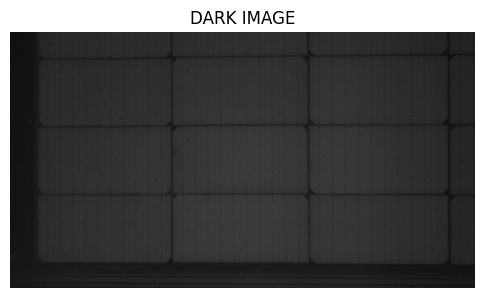

In [10]:
# ════════════════════════════════════════════════════════════════
# IMAGE CLASSIFIER: DARK GRID vs NORMAL GRID
# ════════════════════════════════════════════════════════════════

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# INPUT IMAGE
# ─────────────────────────────────────────────
IMAGE_PATH = "/home/harsh-raj-112/Desktop/Project/27 may/Output/Test10/1/2_cropped.png"   # <-- change image path

# ─────────────────────────────────────────────
# LOAD IMAGE
# ─────────────────────────────────────────────
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Cannot load image: {IMAGE_PATH}")

# ─────────────────────────────────────────────
# CALCULATE FEATURES
# ─────────────────────────────────────────────
mean_val = np.mean(img)      # brightness
std_val  = np.std(img)       # contrast

# Percentage of pixels brighter than 100
bright_ratio = np.sum(img > 100) / img.size

# ─────────────────────────────────────────────
# CLASSIFICATION
# ─────────────────────────────────────────────
MEAN_THRESH = 50
STD_THRESH = 20
BRIGHT_RATIO_THRESH = 0.15

if (
    mean_val < MEAN_THRESH and
    std_val < STD_THRESH and
    bright_ratio < BRIGHT_RATIO_THRESH
):
    label = "DARK IMAGE"
else:
    label = "BRIGHT IMAGE"

# ─────────────────────────────────────────────
# RESULTS
# ─────────────────────────────────────────────
print("=" * 50)
print("IMAGE ANALYSIS")
print("=" * 50)
print(f"Mean Brightness : {mean_val:.2f}")
print(f"Contrast (Std)  : {std_val:.2f}")
print(f"Bright Ratio    : {bright_ratio:.3f}")
print(f"Classification  : {label}")
print("=" * 50)

# ─────────────────────────────────────────────
# DISPLAY IMAGE
# ─────────────────────────────────────────────
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.title(label)
plt.axis("off")
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────
# CONFIG – Camera Intrinsics & Undistortion Parameters
# ─────────────────────────────────────────────────────────────────
IMAGE_PATH = "/home/harsh-raj-112/Desktop/Input/Test5/3.jpeg"   # ← change to your image path
BALANCE    = 0.6                  # 0.0 = tight crop, 1.0 = full FOV

K = np.array([
    [1184.8667983506784, 0.0,                939.9321230074511],
    [0.0,                1182.0885688815326, 604.8672689311147],
    [0.0,                0.0,                1.0]
], dtype=np.float64)

DIST = np.array([
    [ 0.20332565713132572],
    [ 0.042418077818231245],
    [ 0.5625598381701257],
    [-0.6590457476513796]
], dtype=np.float64)

# ─────────────────────────────────────────────────────────────────
# STEP 1 – Fisheye Undistortion
# ─────────────────────────────────────────────────────────────────
img_bgr = cv2.imread(IMAGE_PATH)
assert img_bgr is not None, f"Could not read image: {IMAGE_PATH}"

h, w = img_bgr.shape[:2]

new_K = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
    K, DIST, (w, h), np.eye(3), balance=BALANCE
)
map1, map2 = cv2.fisheye.initUndistortRectifyMap(
    K, DIST, np.eye(3), new_K, (w, h), cv2.CV_16SC2
)
undistorted = cv2.remap(
    img_bgr, map1, map2,
    interpolation=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT
)

print(f"✓ Undistortion complete")
print(f"  Input  : {IMAGE_PATH}  →  {w}×{h}")
print(f"  new_K  :\n{new_K}")

# ─────────────────────────────────────────────────────────────────
# VISUALISE
# ─────────────────────────────────────────────────────────────────
orig_rgb  = cv2.cvtColor(img_bgr,    cv2.COLOR_BGR2RGB)
undist_rgb = cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].imshow(orig_rgb);   axes[0].set_title("Original (distorted)",   fontsize=13)
axes[1].imshow(undist_rgb); axes[1].set_title(f"Undistorted  (balance={BALANCE})", fontsize=13)
for ax in axes: ax.axis("off")
plt.suptitle("Step 1 – Fisheye Undistortion", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# Optional: save
cv2.imwrite("Output/1_undistorted.jpeg", undistorted)